# ssmd spot 1-minute bar features

Explore the **spot-specific** fields on live 1m OHLCV bars returned by
`GET /v1/data/ohlcv/1m?feed={feed}&sym={sym}&limit={n}`.

Each bar object carries:
`sym, o, h, l, c, v, trade_count, taker_buy_volume, taker_sell_volume,
market_order_volume, quote_volume, start_ts_ms, end_ts_ms` (bars ordered oldest→newest).

## Volume: base vs quote currency

Every bar exposes volume in **two currencies**:

| Field | Currency | Description |
|-------|----------|-------------|
| `v` | **Base** (e.g. BTC) | Total quantity of the base asset traded |
| `quote_volume` | **Quote** (e.g. USDT) | Notional value traded = Σ(price × qty) per trade |

`quote_volume` is the USD-denominated turnover for the bar — useful for comparing
activity across assets with very different per-unit prices (e.g. BTC vs DOGE).

## Other spot fields

| Field | Description |
|-------|-------------|
| `trade_count` | Number of individual trades aggregated into the bar |
| `taker_buy_volume` | Volume initiated by buy-side takers (aggressor side) |
| `taker_sell_volume` | Volume initiated by sell-side takers (aggressor side) |
| `market_order_volume` | Volume from market orders (**kraken-spot only**) |

## Exchange coverage caveat

- **binance**: `taker_buy_volume + taker_sell_volume == v` for every bar —
  Binance always reports the aggressor side. `market_order_volume` is always
  **0** because Binance does not expose order type on the public trade stream.
- **kraken-spot**: `taker_buy_volume + taker_sell_volume ≤ v` (some trades carry
  unknown side). `market_order_volume` is populated from the `ord_type` field
  present in kraken-spot trade messages.

Prereqs: `uv pip install requests pandas matplotlib`, then `cp .env.example .env`
and paste your `SSMD_API_KEY`. Launch with `uv run --env-file .env jupyter lab`.

In [1]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Key + base come from the environment. Launch via:
#   uv run --env-file .env jupyter lab
# which loads notebooks/.env into the kernel's environment (no python-dotenv).
API_KEY = os.environ.get('SSMD_API_KEY')
BASE = os.environ.get('SSMD_API_BASE', 'https://api.varshtat.com')
assert API_KEY and not API_KEY.endswith('replace_me'), (
    'SSMD_API_KEY is not set. Copy .env.example to .env, paste your key, and start '
    'Jupyter with: uv run --env-file .env jupyter lab'
)
assert BASE.startswith('https://'), f'SSMD_API_BASE must be https, got: {BASE!r}'


def fetch_bars(feed, sym, limit=60):
    '''Fetch 1m OHLCV bars from the live ring; returns a DataFrame indexed by UTC datetime.

    Returns an empty DataFrame (with a warning printed) if the feed/symbol has no bars.
    The DataFrame index is a DatetimeTZDtype[UTC] built from start_ts_ms.
    '''
    path = '/v1/data/ohlcv/1m'
    try:
        r = requests.get(
            f'{BASE}{path}',
            headers={'X-API-Key': API_KEY},
            params={'feed': feed, 'sym': sym, 'limit': limit},
            timeout=30,
        )
        r.raise_for_status()
        body = r.json()
    except requests.HTTPError as e:
        print(f'[{feed}/{sym}] HTTP error: {e}')
        return pd.DataFrame()

    bars = body.get('bars', [])
    if not bars:
        print(f'[{feed}/{sym}] No bars returned — is the feed live and the symbol correct?')
        return pd.DataFrame()

    df = pd.DataFrame(bars)
    df.index = pd.to_datetime(df['start_ts_ms'], unit='ms', utc=True)
    df.index.name = 'bar_utc'
    return df


print(f'BASE: {BASE}')
print('fetch_bars() ready — key loaded:', bool(API_KEY))

BASE: https://api.varshtat.com
fetch_bars() ready — key loaded: True


In [2]:
SPOT_COLS = ['trade_count', 'v', 'quote_volume', 'taker_buy_volume', 'taker_sell_volume', 'market_order_volume']
# v          = base-asset volume  (e.g. BTC)
# quote_volume = quote-asset volume (e.g. USDT) = Σ(price × qty) per trade

# --- binance spot ---
df_binance = fetch_bars('binance', 'BTCUSDT', limit=60)

if not df_binance.empty:
    print('=== binance / BTCUSDT — last 5 bars ===')
    missing = [c for c in SPOT_COLS if c not in df_binance.columns]
    if missing:
        print(f'  Warning: columns not present: {missing}')
    available = [c for c in SPOT_COLS if c in df_binance.columns]
    display(df_binance[available].tail())
else:
    print('No binance bars to display.')

print()

# --- kraken-spot ---
df_kraken = fetch_bars('kraken-spot', 'BTC/USDT', limit=60)

if not df_kraken.empty:
    print('=== kraken-spot / BTC/USDT — last 5 bars ===')
    missing = [c for c in SPOT_COLS if c not in df_kraken.columns]
    if missing:
        print(f'  Warning: columns not present: {missing}')
    available = [c for c in SPOT_COLS if c in df_kraken.columns]
    display(df_kraken[available].tail())
else:
    print('No kraken-spot bars to display.')

=== binance / BTCUSDT — last 5 bars ===


,trade_count,v,quote_volume,taker_buy_volume,taker_sell_volume,market_order_volume
bar_utc,,,,,,
2026-06-30 13:19:00+00:00,2080,14.58668,8.541485e+05,7.96864,6.61804,0
2026-06-30 13:20:00+00:00,3958,18.22127,1.067286e+06,16.07430,2.14697,0
2026-06-30 13:21:00+00:00,3419,25.06004,1.468141e+06,18.58555,6.47449,0
2026-06-30 13:22:00+00:00,1678,10.26899,6.012097e+05,4.69983,5.56916,0
2026-06-30 13:23:00+00:00,772,3.86269,2.260694e+05,0.38236,3.48033,0


=== kraken-spot / BTC/USDT — last 5 bars ===


,trade_count,v,quote_volume,taker_buy_volume,taker_sell_volume,market_order_volume
bar_utc,,,,,,
2026-06-30 13:19:00+00:00,2,0.035848,2099.388583,0.010000,0.025848,0.010000
2026-06-30 13:20:00+00:00,1,0.000075,4.390038,0.000075,0.000000,0.000000
2026-06-30 13:21:00+00:00,5,0.055951,3278.183222,0.055951,0.000000,0.010085
2026-06-30 13:22:00+00:00,6,0.184566,10811.524539,0.004808,0.179758,0.002051
2026-06-30 13:23:00+00:00,1,0.000140,8.194536,0.000000,0.000140,0.000000


### Volume columns: base vs quote

| Column | Currency | Meaning |
|--------|----------|---------|
| `v` | **Base** (BTC) | Quantity of the base asset that changed hands |
| `quote_volume` | **Quote** (USDT) | Notional traded = Σ(price × qty) across all trades in the bar |

`quote_volume` is the dollar-denominated turnover. For a BTC bar with 1.5 BTC traded at ~$62 000,
expect `quote_volume ≈ 93 000`. Because it is price-weighted, it is the right metric for comparing
liquidity across assets or across time periods with different price levels.

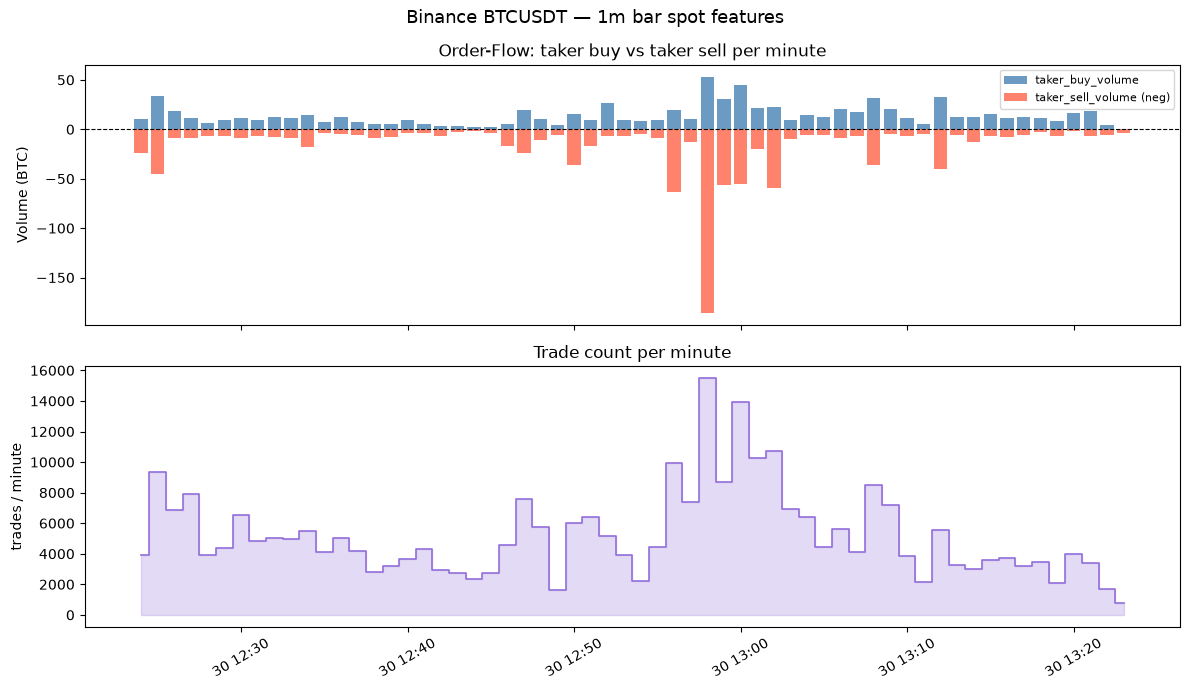

In [3]:
# Order-flow imbalance for binance BTCUSDT.
# taker_buy_volume is plotted upward; taker_sell_volume is mirrored downward.
# For binance these always sum to v (Binance always reports the aggressor side).
# A second subplot shows trade count per minute.
if df_binance.empty:
    print('No binance data — skipping plots.')
elif not {'taker_buy_volume', 'taker_sell_volume', 'trade_count'}.issubset(df_binance.columns):
    print('Required columns missing from binance bars — skipping plots.')
else:
    # matplotlib date units are days; 0.8 min / 1440 min-per-day ≈ 0.000556
    bar_w = 0.8 / 1440

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle('Binance BTCUSDT — 1m bar spot features', fontsize=13)

    # subplot 1: order-flow imbalance
    ax1.bar(
        df_binance.index,
        df_binance['taker_buy_volume'],
        width=bar_w,
        color='steelblue',
        label='taker_buy_volume',
        alpha=0.8,
    )
    ax1.bar(
        df_binance.index,
        -df_binance['taker_sell_volume'],
        width=bar_w,
        color='tomato',
        label='taker_sell_volume (neg)',
        alpha=0.8,
    )
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.set_ylabel('Volume (BTC)')
    ax1.set_title('Order-Flow: taker buy vs taker sell per minute')
    ax1.legend(fontsize=8)

    # subplot 2: trade count
    ax2.step(
        df_binance.index,
        df_binance['trade_count'],
        where='mid',
        color='mediumpurple',
        linewidth=1.2,
    )
    ax2.fill_between(
        df_binance.index,
        df_binance['trade_count'],
        alpha=0.25,
        color='mediumpurple',
        step='mid',
    )
    ax2.set_ylabel('trades / minute')
    ax2.set_title('Trade count per minute')
    ax2.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

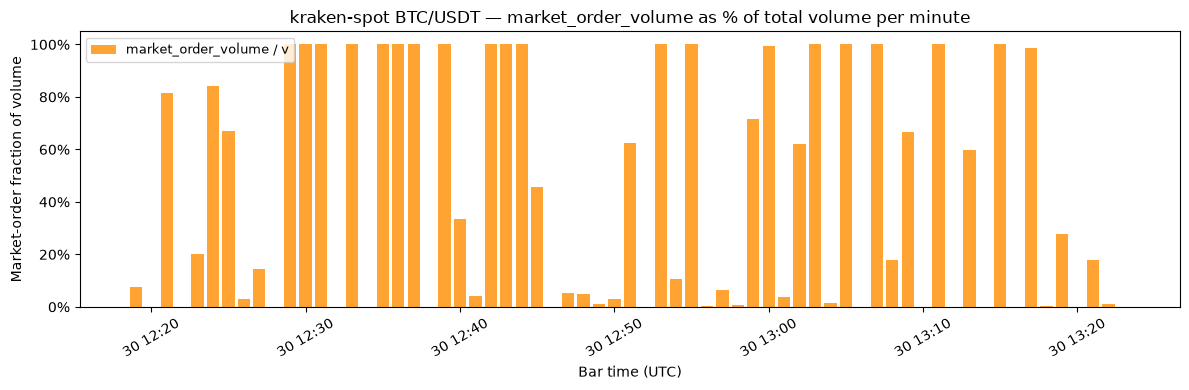

Mean market-order fraction: 46.4%  |  Max: 100.0%


In [4]:
# kraken-spot: market_order_volume as a fraction of total volume per minute.
# Binance always reports 0 here (order type not on public stream).
if df_kraken.empty:
    print('No kraken-spot data — skipping market_order_volume plot.')
elif not {'market_order_volume', 'v'}.issubset(df_kraken.columns):
    print('market_order_volume or v column not present — check API version.')
else:
    bar_w = 0.8 / 1440

    # Guard against zero-volume bars before dividing.
    frac = df_kraken['market_order_volume'] / df_kraken['v'].replace(0, float('nan'))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(
        df_kraken.index,
        frac,
        width=bar_w,
        color='darkorange',
        alpha=0.8,
        label='market_order_volume / v',
    )
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel('Market-order fraction of volume')
    ax.set_title('kraken-spot BTC/USDT — market_order_volume as % of total volume per minute')
    ax.set_xlabel('Bar time (UTC)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f'Mean market-order fraction: {frac.mean():.1%}  |  Max: {frac.max():.1%}')

## Note on `market_order_volume` availability

`market_order_volume` is **kraken-spot only**. It is populated from the `ord_type`
field present in kraken-spot trade messages, which identifies whether each trade
was initiated by a market order or a limit order at the exchange level.

**Binance** does not expose order type on the public trade stream, so
`market_order_volume` is always **0** for binance bars — this is not a data gap,
just a feed capability difference.

To list all available symbols for a feed:
`GET /v1/data/ohlcv/1m/symbols?feed={feed}`

## Binance 1m-bar reconciliation: our WS bars vs Binance REST klines

This section validates the accuracy of our WebSocket-derived 1m OHLCV bars for
`binance/BTCUSDT` against Binance's own authoritative REST kline endpoint.

### What is validated

| Our field | REST field (index) | Description |
|-----------|-------------------|-------------|
| `c` | `[4]` close | Close price — should match near-exactly (deterministic) |
| `v` | `[5]` base vol | Base-asset (BTC) volume — tiny diffs from boundary/late trades |
| `quote_volume` | `[7]` quote vol | Notional (USDT) = Σ(price×qty) — same boundary caveat |
| `trade_count` | `[8]` n\_trades | Trade count — same caveat |
| `taker_buy_volume` | `[9]` taker buy base | Buy-aggressor base volume |

### Why small divergence is expected

Our bars are built from the **live WebSocket trade stream** captured at pod start.
The bar-cache ring only holds bars since the last pod restart (typically ~1 hour).
Binance REST klines are authoritative server-side aggregations. Tiny differences
can arise from:

- **Boundary trades**: trades whose exchange timestamp sits exactly on a minute
  boundary may be assigned to different bars by the WS stream vs REST aggregation.
- **Late messages**: trades delivered out-of-order over WebSocket.
- **Our ring start**: bars from before the pod restart are absent — the overlap
  is naturally limited to recent completed minutes.

`quote_volume` (`q` in Binance nomenclature, index [7]) is Σ(price×qty) over all
trades in the bar — identical definition to our `quote_volume` field. These should
agree closely; any divergence indicates a missed or duplicate trade on our side.

**The still-forming current minute is excluded from both sides** before comparing.

Our bars:   60 rows  [2026-06-30 12:24:00+00:00 … 2026-06-30 13:23:00+00:00]
REST klines:120 rows  [2026-06-30 11:24:00+00:00 … 2026-06-30 13:23:00+00:00]

After excluding forming minute:
  Our bars (closed):  59
  REST klines (closed): 119

Overlapping closed minutes: 59

=== Per-minute comparison (last 10 closed bars) ===


,reldiff_close,reldiff_base_volume,reldiff_quote_volume,reldiff_trade_count,reldiff_taker_buy_volume
bar_utc,,,,,
2026-06-30 13:13:00+00:00,-,-,-,-,-
2026-06-30 13:14:00+00:00,0.00003,-,-,-,-
2026-06-30 13:15:00+00:00,-,-,-,-,-
2026-06-30 13:16:00+00:00,0.00001,-,-,-,-
2026-06-30 13:17:00+00:00,-,-,-,-,-
2026-06-30 13:18:00+00:00,-,-,-,-,-
2026-06-30 13:19:00+00:00,-,-,-,-,-
2026-06-30 13:20:00+00:00,-,-,-,-,-
2026-06-30 13:21:00+00:00,-,-,-,-,-



=== RECONCILIATION SUMMARY (59 closed minutes compared) ===
Field                    Median rel diff    Max rel diff
----------------------------------------------------------
close                                  -         0.00003
base_volume                            -               -
quote_volume                           -               -
trade_count                            -               -
taker_buy_volume                       -               -

Interpretation:
  close price  : deterministic — expect ~0 diff (any divergence = wrong bar alignment)
  volume fields: small diffs (~0.01–0.1%) are normal — boundary/late trades
  quote_volume : checked against Binance q-field (index [7]); should track v diffs closely
  trade_count  : integer — exact match expected except at bar boundaries
  diffs below EPSILON (1e-6) shown as '-' (exact agreement within float rounding)


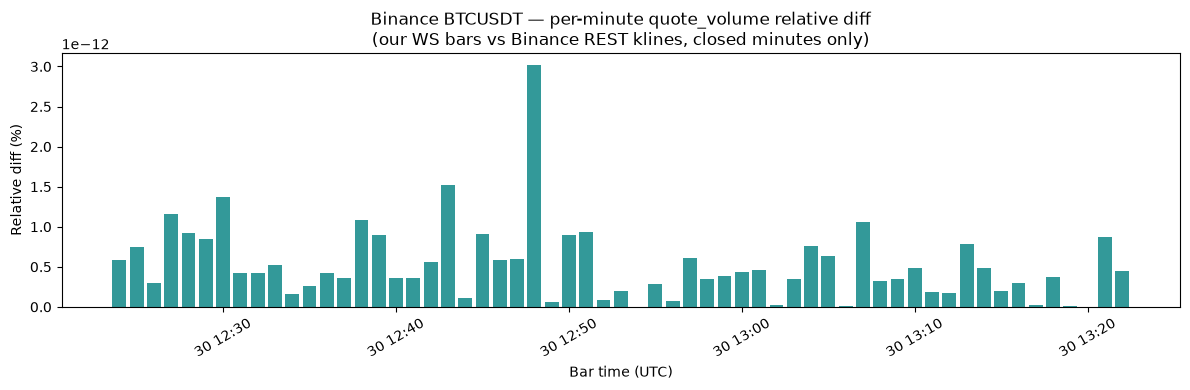

In [5]:
# ---------------------------------------------------------------------------
# Fixed-decimal display (no scientific notation) for this section's tables.
# ---------------------------------------------------------------------------
pd.set_option('display.float_format', lambda x: f'{x:.5f}')

# ---------------------------------------------------------------------------
# Binance REST klines — fetched from data-api.binance.vision (NOT api.binance.com,
# which returns HTTP 451 in US regions). No auth required.
# ---------------------------------------------------------------------------
BINANCE_KLINES_URL = 'https://data-api.binance.vision/api/v3/klines'

def fetch_binance_rest_klines(symbol='BTCUSDT', interval='1m', limit=120):
    '''Fetch Binance REST klines; returns DataFrame indexed by UTC open-time datetime.

    All kline fields are returned as strings by the API — this function parses them.
    Columns: rest_o, rest_h, rest_l, rest_c, rest_v, rest_quote_volume,
             rest_trade_count, rest_taker_buy_volume, close_time_ms.
    '''
    r = requests.get(
        BINANCE_KLINES_URL,
        params={'symbol': symbol, 'interval': interval, 'limit': limit},
        timeout=30,
    )
    r.raise_for_status()
    data = r.json()
    if not data or not isinstance(data, list):
        raise ValueError(f'Binance klines returned unexpected payload: {data!r}')

    rows = []
    for k in data:
        rows.append({
            'open_time_ms':        int(k[0]),
            'rest_o':              float(k[1]),
            'rest_h':              float(k[2]),
            'rest_l':              float(k[3]),
            'rest_c':              float(k[4]),
            'rest_v':              float(k[5]),   # base volume
            'close_time_ms':       int(k[6]),
            'rest_quote_volume':   float(k[7]),   # quote asset volume
            'rest_trade_count':    int(k[8]),
            'rest_taker_buy_volume': float(k[9]), # taker buy base volume
        })

    df = pd.DataFrame(rows)
    df.index = pd.to_datetime(df['open_time_ms'], unit='ms', utc=True)
    df.index.name = 'bar_utc'
    return df


# ---------------------------------------------------------------------------
# Fetch data
# ---------------------------------------------------------------------------
ours_raw = fetch_bars('binance', 'BTCUSDT', limit=120)
rest_raw = fetch_binance_rest_klines(symbol='BTCUSDT', limit=120)

if ours_raw.empty:
    raise RuntimeError('Our binance bars are empty — is the feed live?')

print(f'Our bars:   {len(ours_raw)} rows  [{ours_raw.index[0]} … {ours_raw.index[-1]}]')
print(f'REST klines:{len(rest_raw)} rows  [{rest_raw.index[0]} … {rest_raw.index[-1]}]')

# ---------------------------------------------------------------------------
# Exclude the still-forming current minute from BOTH sides.
# A bar's minute is "closed" when its close time (bar_utc + 60s) is in the past.
# ---------------------------------------------------------------------------
now = pd.Timestamp.now('UTC')

ours = ours_raw[ours_raw.index + pd.Timedelta(seconds=60) < now].copy()
rest = rest_raw[
    pd.to_datetime(rest_raw['close_time_ms'], unit='ms', utc=True) < now
].copy()

print(f'\nAfter excluding forming minute:')
print(f'  Our bars (closed):  {len(ours)}')
print(f'  REST klines (closed): {len(rest)}')

# ---------------------------------------------------------------------------
# Inner join on UTC minute index (our ring ∩ REST klines)
# ---------------------------------------------------------------------------
joined = ours.join(rest[['rest_o','rest_h','rest_l','rest_c','rest_v',
                          'rest_quote_volume','rest_trade_count',
                          'rest_taker_buy_volume']], how='inner')

n_overlap = len(joined)
print(f'\nOverlapping closed minutes: {n_overlap}')

if n_overlap == 0:
    print(
        '\n[!] No overlap between our ring and REST klines.\n'
        '    This is expected immediately after a bar-cache pod restart.\n'
        '    Wait a few minutes for the ring to accumulate bars, then re-run.'
    )
else:
    # -----------------------------------------------------------------------
    # Relative difference helper: abs(ours - rest) / rest, guard /0
    # -----------------------------------------------------------------------
    def rel_diff(a, b):
        denom = b.abs().replace(0, float('nan'))
        return (a - b).abs() / denom

    fields = [
        ('close',             'c',                 'rest_c'),
        ('base_volume',       'v',                 'rest_v'),
        ('quote_volume',      'quote_volume',       'rest_quote_volume'),
        ('trade_count',       'trade_count',        'rest_trade_count'),
        ('taker_buy_volume',  'taker_buy_volume',   'rest_taker_buy_volume'),
    ]

    # Comparison table: per-minute values + relative diff
    cmp_rows = {}
    for label, our_col, rest_col in fields:
        if our_col not in joined.columns or rest_col not in joined.columns:
            print(f'  [skip] {label}: column not present (our={our_col}, rest={rest_col})')
            continue
        cmp_rows[f'ours_{label}']  = joined[our_col]
        cmp_rows[f'rest_{label}']  = joined[rest_col]
        cmp_rows[f'reldiff_{label}'] = rel_diff(
            joined[our_col].astype(float),
            joined[rest_col].astype(float),
        )

    cmp = pd.DataFrame(cmp_rows)

    # -----------------------------------------------------------------------
    # Diff formatting: values below EPSILON (1e-6) render as '-' (exact
    # agreement within float rounding); otherwise fixed 5 decimals, no sci
    # notation. Applies to BOTH the per-minute table and the summary stats.
    # (Value columns like prices/volumes keep plain 5-decimal formatting.)
    # -----------------------------------------------------------------------
    EPSILON = 1e-6

    def fmt_diff(v):
        if pd.isna(v):
            return 'n/a'
        return '-' if abs(v) < EPSILON else f'{v:.5f}'

    print('\n=== Per-minute comparison (last 10 closed bars) ===')
    # Show just the reldiff columns for compactness — dash rule, no sci notation.
    reldiff_cols = [c for c in cmp.columns if c.startswith('reldiff_')]
    display(cmp[reldiff_cols].tail(10).style.format(fmt_diff))

    # -----------------------------------------------------------------------
    # Summary: median and max relative diff per field (dash rule, no sci notation).
    # -----------------------------------------------------------------------
    print(f'\n=== RECONCILIATION SUMMARY ({n_overlap} closed minutes compared) ===')
    print(f'{"Field":<22}  {"Median rel diff":>16}  {"Max rel diff":>14}')
    print('-' * 58)
    for label, our_col, rest_col in fields:
        col = f'reldiff_{label}'
        if col not in cmp.columns:
            continue
        median_d = cmp[col].median()
        max_d    = cmp[col].max()
        flag = '  *** LARGE' if (pd.notna(max_d) and max_d > 0.01) else ''
        print(f'{label:<22}  {fmt_diff(median_d):>16}  {fmt_diff(max_d):>14}{flag}')

    print()
    print('Interpretation:')
    print('  close price  : deterministic — expect ~0 diff (any divergence = wrong bar alignment)')
    print('  volume fields: small diffs (~0.01–0.1%) are normal — boundary/late trades')
    print('  quote_volume : checked against Binance q-field (index [7]); should track v diffs closely')
    print('  trade_count  : integer — exact match expected except at bar boundaries')
    print("  diffs below EPSILON (1e-6) shown as '-' (exact agreement within float rounding)")

    # -----------------------------------------------------------------------
    # Plot: per-minute relative diff for quote_volume
    # -----------------------------------------------------------------------
    if 'reldiff_quote_volume' in cmp.columns and not cmp['reldiff_quote_volume'].isna().all():
        bar_w = 0.8 / 1440
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(
            cmp.index,
            cmp['reldiff_quote_volume'] * 100,
            width=bar_w,
            color='teal',
            alpha=0.8,
        )
        ax.set_ylabel('Relative diff (%)')
        ax.set_title(
            'Binance BTCUSDT — per-minute quote_volume relative diff\n'
            '(our WS bars vs Binance REST klines, closed minutes only)'
        )
        ax.set_xlabel('Bar time (UTC)')
        ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.show()